# D8 e D9 — Integração com Sistemas Corporativos (ERP, HIS)

## Demonstração Prática — UNIMED SP

**Prof. Pedro | Simulação em Serviços de Saúde**

---

### 📋 Sobre este notebook

Este notebook é a **parte prática** da aula D8 e D9. Ele mostra, passo a passo, como dados reais de sistemas hospitalares são extraídos, limpos e transformados em **inputs para um modelo de simulação de eventos discretos**.

### 🗺️ Jornada deste notebook

```
PARTE 1 — Conexão ao HIS (FHIR)
  └─ Entender o protocolo HL7 FHIR R4
  └─ Fazer chamadas REST à API hospitalar
  └─ Interpretar o recurso Encounter

PARTE 2 — Dataset sintético realista
  └─ Por que gerar dados sintéticos?
  └─ Processo de Poisson para chegadas
  └─ Distribuição Lognormal para tempos de serviço
  └─ Protocolo Manchester de triagem

PARTE 3 — Qualidade de dados
  └─ Análise de completude por campo
  └─ Detecção e remoção de outliers (método IQR)
  └─ Visualização: antes × depois da limpeza

PARTE 4 — KPIs operacionais
  └─ Taxa de chegada por hora do dia
  └─ Volume por dia da semana
  └─ Tempo de espera por nível de risco
  └─ Heatmap hora × dia (padrão de demanda)

PARTE 5 — Integração com ERP
  └─ Escala de pessoal (query SQL simulada)
  └─ Disponibilidade de leitos
  └─ Ocupação por ala hospitalar

PARTE 6 — Conformidade LGPD
  └─ Classificação de sensibilidade de campos
  └─ Quais dados podem ir para o simulador?

PARTE 7 — Tabela de inputs para o simulador
  └─ Taxa de chegada por faixa horária
  └─ Tempo médio de serviço por nível de risco
  └─ Exportação em CSV pronto para uso
```

### ⏱️ Tempo estimado de execução: ~2 minutos (com internet) ou ~30 segundos (modo offline)

> **Como usar:** Execute as células em ordem, de cima para baixo. Cada seção começa com uma explicação teórica e termina com uma interpretação dos resultados.


---

## Parte 1 — Configuração do Ambiente

### Por que essas bibliotecas?

| Biblioteca    | Para que serve neste notebook                          |
| ------------- | ------------------------------------------------------ |
| `requests`    | Fazer chamadas HTTP à API FHIR (GET, POST)             |
| `pandas`      | Organizar dados em tabelas (DataFrames)                |
| `numpy`       | Cálculos numéricos, geração de números aleatórios      |
| `matplotlib`  | Criar gráficos de linha, barra e heatmap               |
| `seaborn`     | Gráficos estatísticos com visual aprimorado            |
| `scipy.stats` | Distribuições estatísticas (Poisson, Lognormal, Expon) |
| `datetime`    | Manipulação de datas e horários dos atendimentos       |

> 💡 **Conceito — Ecossistema de dados hospitalares:** Em um hospital real, esses dados viriam de sistemas diferentes — o `requests` simula o cliente que faz a integração entre eles.


In [113]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# Execute esta célula apenas se algum import falhar na célula seguinte.
# O símbolo '!' executa um comando do terminal diretamente no notebook.
# ─────────────────────────────────────────────────────────────────

# !pip install requests pandas matplotlib seaborn scipy numpy

In [114]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 2 — Importação de bibliotecas e configurações globais
# ─────────────────────────────────────────────────────────────────

import requests  # Chamadas HTTP para API FHIR
import pandas as pd  # Manipulação de dados tabulares
import numpy as np  # Operações numéricas e random seeds
import matplotlib.pyplot as plt  # Geração de gráficos
import matplotlib.ticker as mticker
import seaborn as sns  # Gráficos estatísticos
from datetime import datetime, timedelta
import random
import warnings

warnings.filterwarnings("ignore")

# ── Paleta de cores alinhada com a identidade visual do curso ──
AZUL = "#1F4E79"
AZUL2 = "#2E75B6"
VERDE = "#1D6A39"
LARANJA = "#E36C09"

# ── Estilo global dos gráficos ──
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_theme(style="whitegrid", palette="Blues_d")

print("✅ Ambiente configurado com sucesso!")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")

✅ Ambiente configurado com sucesso!
   pandas  3.0.3 | numpy 2.4.4


---

## Parte 2 — Conexão ao HIS via HL7 FHIR R4

### 🏥 O que é HL7 FHIR?

**FHIR** (Fast Healthcare Interoperability Resources) é o **padrão internacional de interoperabilidade em saúde**, publicado pela HL7 International. A versão atual é a **R4** (Release 4, 2019).

**Por que FHIR importa para simulação?**
Porque ele fornece dados estruturados e padronizados sobre:

- Atendimentos (`Encounter`) → calibram a **taxa de chegada**
- Procedimentos (`Procedure`) → calibram o **tempo de serviço**
- Disponibilidade de leitos (`Location`) → definem a **capacidade**

### 🌐 Como funciona uma API FHIR?

FHIR usa a arquitetura **REST** (Representational State Transfer). É o mesmo padrão de APIs usado por aplicativos web comuns.

```
Verbo HTTP   Operação FHIR         Exemplo
──────────   ─────────────────     ──────────────────────────────────
GET          Ler / Buscar          GET /Encounter?class=EMER
POST         Criar                 POST /Patient  (body: JSON)
PUT          Atualizar             PUT /Encounter/123
DELETE       Excluir               DELETE /Observation/456
```

### 🧪 Servidor de testes: HAPI FHIR Public Sandbox

Usamos o servidor público **`hapi.fhir.org/baseR4`**, mantido pela **Smile CDR** (empresa canadense de interoperabilidade). É gratuito, aberto e usado mundialmente para testes e treinamentos.

> ⚠️ **Atenção:** Este servidor pode estar lento ou indisponível. O notebook detecta automaticamente e gera dados sintéticos realistas como fallback

### 🔐 Segurança: OAuth 2.0 e HTTPS

Em produção, toda API FHIR usa **OAuth 2.0** (RFC 6749) para autenticação:

```
1. Sistema solicita token ao Authorization Server
2. Authorization Server valida credenciais e emite JWT
3. Sistema inclui token no cabeçalho: Authorization: Bearer <token>
4. FHIR Server valida o token antes de responder
```

No sandbox de testes, a autenticação é desabilitada para facilitar o aprendizado.


In [115]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configuração da conexão FHIR
# ─────────────────────────────────────────────────────────────────

# URL base do servidor FHIR (trocar por URL interna em produção)
FHIR_BASE = "https://hapi.fhir.org/baseR4"

# Cabeçalhos HTTP obrigatórios para APIs FHIR:
# - Accept: informa que queremos a resposta em JSON (não XML)
# - Content-Type: formato dos dados que enviamos (em POST/PUT)
HEADERS = {"Accept": "application/fhir+json", "Content-Type": "application/fhir+json"}

# Timeout: quanto tempo (segundos) esperamos a resposta antes de desistir
# Em produção, ajustar conforme a infraestrutura de rede
TIMEOUT = 10


def fhir_get(path, params=None):
    """
    Executa GET em um endpoint FHIR e retorna (dados, sucesso).

    Parâmetros:
      path   : recurso FHIR, ex: 'Encounter', 'Patient/123'
      params : dicionário de filtros de busca, ex: {'class': 'EMER'}

    Retorno:
      (dict, True)  → sucesso, dados do servidor real
      (None, False) → falha, usar dados sintéticos
    """
    url = f"{FHIR_BASE}/{path}"

    print(f"🔍 GET {url} | params={params}")
    try:
        # Requisição HTTP GET com headers e timeout definidos
        resp = requests.get(url, headers=HEADERS, params=params, timeout=TIMEOUT)

        # raise_for_status() lança exceção se status HTTP >= 400
        resp.raise_for_status()

        # Converte o corpo da resposta (JSON) para dict Python
        return resp.json(), True

    except Exception as e:
        # Qualquer erro (rede, timeout, HTTP 4xx/5xx) cai aqui
        print(f"⚠️  Servidor FHIR indisponível: {type(e).__name__}")
        print("   → Usando dataset sintético realista como fallback.")
        return None, False


# Teste de conectividade
print("🔌 Testando conexão ao servidor FHIR...")
result, ok = fhir_get("metadata")  # /metadata retorna o CapabilityStatement do servidor
if ok:
    software = result.get("software", {})
    print(
        f"✅ Conectado: {software.get('name','FHIR Server')} v{software.get('version','?')}"
    )
    print(f"   URL: {FHIR_BASE}")
else:
    print("   Modo offline ativado — dados sintéticos serão usados.")

🔌 Testando conexão ao servidor FHIR...
🔍 GET https://hapi.fhir.org/baseR4/metadata | params=None
✅ Conectado: HAPI FHIR Server v8.9.4-SNAPSHOT/eee190b153/2026-02-26
   URL: https://hapi.fhir.org/baseR4


---

## Parte 3 — Extração de Atendimentos (Recurso `Encounter`)

### 📄 O que é um Encounter?

No vocabulário FHIR, **`Encounter`** representa qualquer episódio de interação entre um paciente e o sistema de saúde. É o recurso mais importante para simulação de PA porque contém:

| Campo FHIR     | Significado                             | Uso na simulação                |
| -------------- | --------------------------------------- | ------------------------------- |
| `status`       | situação atual (finished, in-progress)  | filtrar atendimentos completos  |
| `class`        | tipo de atendimento (EMER = emergência) | selecionar apenas PA            |
| `period.start` | horário de entrada                      | calcular taxa de chegada λ      |
| `period.end`   | horário de saída                        | calcular tempo de permanência   |
| `priority`     | urgência (triagem)                      | distribuição por nível de risco |
| `location`     | leito/sala ocupada                      | capacidade do recurso           |

### 📦 Estrutura de resposta: Bundle FHIR

Quando buscamos múltiplos recursos, FHIR retorna um **Bundle** — um "pacote" que agrupa os resultados:

```json
{
  "resourceType": "Bundle",
  "type": "searchset",
  "total": 1847,           ← total de registros no servidor
  "link": [
    { "relation": "next",
      "url": "...?_getpages=abc&_getpagesoffset=20" }
  ],
  "entry": [
    {
      "resource": {
        "resourceType": "Encounter",
        "id": "12345",
        "status": "finished",
        "class": { "code": "EMER", "display": "emergency" },
        "period": {
          "start": "2024-11-10T14:23:00+00:00",
          "end":   "2024-11-10T16:45:00+00:00"
        }
      }
    }
  ]
}
```

> 💡 **Paginação:** O FHIR retorna no máximo `_count` registros por página. Para obter todos, precisamos seguir o link `next` — exatamente como as páginas de resultados do Google.


In [116]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 4 — Busca de Encounters de emergência via FHIR
# ─────────────────────────────────────────────────────────────────

# Parâmetros da busca — equivalem à cláusula WHERE de um SQL:
# class=EMER        → apenas atendimentos de emergência
# status=finished   → atendimentos concluídos (têm data de saída)
# _count=50         → máximo de 50 registros por página
params_encounter = {"class": "EMER", "status": "finished", "_count": "50"}

print("📡 Consultando Encounters de emergência no servidor FHIR...")
bundle, online = fhir_get("Encounter", params=params_encounter)

encounters_raw = []  # lista que vai acumular os atendimentos

if online and bundle:
    # O Bundle tem uma lista 'entry'; cada item tem um campo 'resource'
    entries = bundle.get("entry", [])
    total_servidor = bundle.get("total", "?")

    for entry in entries:
        resource = entry.get("resource", {})

        # Extraímos apenas os campos relevantes para simulação
        enc = {
            "id": resource.get("id"),
            "status": resource.get("status"),
            # class é um código — ex: {'code': 'EMER', 'display': 'emergency'}
            "class": resource.get("class", {}).get("code"),
            # period tem start e end em formato ISO 8601
            "start": resource.get("period", {}).get("start"),
            "end": resource.get("period", {}).get("end"),
            # priority também é um CodeableConcept
            "priority": resource.get("priority", {}).get("coding", [{}])[0].get("code"),
        }
        encounters_raw.append(enc)

    print(f"✅ Total no servidor: {total_servidor} Encounters")
    print(f"   Retornados nesta página: {len(entries)}")
    print(f"   Extraídos com sucesso:   {len(encounters_raw)}")

    # Mostra os 3 primeiros registros para inspeção
    if encounters_raw:
        print("\n📋 Exemplo dos 3 primeiros Encounters extraídos:")
        df_preview = pd.DataFrame(encounters_raw[:3])
        print(df_preview.to_string(index=False))
else:
    print(
        "ℹ️  Modo offline — Encounters serão gerados sinteticamente na próxima seção."
    )

📡 Consultando Encounters de emergência no servidor FHIR...
🔍 GET https://hapi.fhir.org/baseR4/Encounter | params={'class': 'EMER', 'status': 'finished', '_count': '50'}
✅ Total no servidor: ? Encounters
   Retornados nesta página: 50
   Extraídos com sucesso:   50

📋 Exemplo dos 3 primeiros Encounters extraídos:
       id   status class                start                  end priority
105794636 finished  EMER 2025-02-15T22:10:00Z 2025-02-15T23:00:00Z     None
105794638 finished  EMER 2025-05-22T03:20:00Z 2025-05-22T04:05:00Z     None
131287955 finished  EMER 2025-06-10T08:00:00Z 2025-06-10T18:00:00Z     None


---

## Parte 4 — Dataset Sintético Realista do PA

### 🤔 Por que dados sintéticos?

O servidor FHIR público contém dados de teste genéricos que **não representam padrões reais de um PA brasileiro**. Em um projeto real, os dados viriam do HIS interno — mas para nosso treinamento, precisamos de dados que:

1. Sejam **estatisticamente coerentes** com a literatura de PA
2. Respeitem a **LGPD** (dados de pacientes reais exigem anonimização)
3. Possam ser **reproduzidos** (seed fixo → mesmo resultado toda vez)
4. Sejam ricos o suficiente para **demonstrar todos os conceitos**

### 📊 Modelos estatísticos utilizados

#### 1. Processo de Poisson — chegadas de pacientes

O **Processo de Poisson** é o modelo padrão para chegadas aleatórias em filas. A premissa é que chegadas são **independentes entre si** e ocorrem a uma **taxa média λ** (lambda) por unidade de tempo.

```
P(X = k) = (λᵏ · e⁻λ) / k!

Onde:
  X = número de chegadas no intervalo
  λ = taxa média de chegadas (ex: 4,2 pacientes/hora)
  k = número inteiro de chegadas observadas
```

**No PA da UNIMED-SP**, λ varia ao longo do dia:

- Madrugada (0h–5h): λ ≈ 1,5–2,0 pac/hora (mínimo)
- Manhã (8h–12h): λ ≈ 6,0–8,0 pac/hora
- Pico vespertino (17h–19h): λ ≈ 9,1 pac/hora (máximo)
- Queda noturna (21h–23h): λ ≈ 4,0–5,0 pac/hora

#### 2. Distribuição Lognormal — tempos de serviço

Tempos de atendimento clínico têm distribuição **assimétrica à direita** — a maioria dos atendimentos é rápida, mas casos complexos podem demorar muito. A **Lognormal** captura isso bem:

```
Se T ~ Lognormal(μ, σ²), então log(T) ~ Normal(μ, σ²)

E[T] = e^(μ + σ²/2)     ← média real do tempo
```

#### 3. Protocolo de Manchester — classificação de risco

O **Protocolo de Manchester** é o sistema de triagem adotado pela UNIMED-SP e pela maioria dos hospitais brasileiros de grande porte:

| Cor         | Risco         | Tempo máximo para atendimento | Proporção típica no PA |
| ----------- | ------------- | ----------------------------- | ---------------------- |
| 🔴 Vermelho | Emergência    | Imediato (0 min)              | 5%                     |
| 🟠 Laranja  | Muito urgente | 10 minutos                    | 15%                    |
| 🟡 Amarelo  | Urgente       | 60 minutos                    | 30%                    |
| 🟢 Verde    | Pouco urgente | 120 minutos                   | 40%                    |
| 🔵 Azul     | Não urgente   | 240 minutos                   | 10%                    |

### 🔁 Reprodutibilidade — Por que `random.seed(42)`?

Fixar a semente garante que toda execução gere **exatamente os mesmos dados**. Isso é essencial para:

- **Comparar cenários** ("e se aumentarmos 1 médico?")
- **Reproduzir resultados** em artigos e relatórios
- **Debugar modelos** sem variação aleatória confundindo a análise


In [117]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 5 — Geração do dataset sintético do PA
# 30 dias de operação com ~4.000 atendimentos simulados
# ─────────────────────────────────────────────────────────────────

# Semente fixa → resultados reproduzíveis em qualquer máquina
random.seed(42)
np.random.seed(42)

# ── Parâmetros do processo de Poisson (λ por hora do dia) ──────
# Fonte: literatura de PA brasileiros (Paim et al., 2011; ANS, 2023)
TAXA_CHEGADA = {
    0: 1.5,
    1: 1.2,
    2: 1.0,
    3: 0.8,
    4: 0.9,
    5: 1.3,
    6: 2.5,
    7: 4.0,
    8: 6.0,
    9: 7.2,
    10: 7.8,
    11: 8.0,
    12: 7.5,
    13: 6.8,
    14: 6.5,
    15: 7.0,
    16: 8.2,
    17: 9.1,
    18: 8.8,
    19: 7.5,
    20: 6.5,
    21: 5.5,
    22: 4.5,
    23: 3.0,
}

# ── Parâmetros por nível de risco (Lognormal para tempos) ──────
# μ e σ são os parâmetros da distribuição do log(tempo em horas)
# proporção = fração dos atendimentos neste nível
RISCO_PARAMS = {
    "Vermelho": {"mu": 3.0, "sigma": 0.3, "prop": 0.05},  # ~20 min med.
    "Laranja": {"mu": 3.5, "sigma": 0.4, "prop": 0.15},  # ~33 min med.
    "Amarelo": {"mu": 4.2, "sigma": 0.5, "prop": 0.30},  # ~67 min med.
    "Verde": {"mu": 4.8, "sigma": 0.6, "prop": 0.40},  # ~121 min med.
    "Azul": {"mu": 3.8, "sigma": 0.4, "prop": 0.10},  # ~45 min med.
}

NIVEIS_RISCO = list(RISCO_PARAMS.keys())
PROPS_RISCO = [RISCO_PARAMS[r]["prop"] for r in NIVEIS_RISCO]

# ── Nomes dos dias da semana em português ─────────────────────
DIAS_SEMANA = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]

# ── Geração do dataset — 30 dias ──────────────────────────────
dt_inicio = datetime(2024, 11, 1, 0, 0, 0)  # início da simulação
registros = []
id_counter = 1

for dia in range(30):  # itera pelos 30 dias
    for hora in range(24):  # itera pelas 24 horas de cada dia

        # λ desta hora do dia
        lam = TAXA_CHEGADA[hora]

        # Número de chegadas nesta hora — sorteio Poisson
        n_chegadas = np.random.poisson(lam)

        for _ in range(n_chegadas):

            # Minuto e segundo aleatório dentro da hora
            min_chegada = random.randint(0, 59)
            seg_chegada = random.randint(0, 59)
            dt_chegada = dt_inicio + timedelta(
                days=dia, hours=hora, minutes=min_chegada, seconds=seg_chegada
            )

            # Nível de risco Manchester — sorteio conforme proporções
            risco = np.random.choice(NIVEIS_RISCO, p=PROPS_RISCO)
            p = RISCO_PARAMS[risco]

            # Tempos de espera e atendimento — distribuição Lognormal
            # np.random.lognormal(mean, sigma) retorna o valor já exponenciado
            t_triagem = np.random.lognormal(2.5, 0.5)  # espera até triagem (min)
            t_medico = np.random.lognormal(
                p["mu"] - 1.5, p["sigma"]
            )  # espera até médico
            t_atend = np.random.lognormal(p["mu"], p["sigma"])  # atendimento

            # 5% de dados faltantes — simulam falhas de registro do HIS
            if random.random() < 0.05:
                t_triagem = np.nan
            if random.random() < 0.05:
                t_medico = np.nan

            registros.append(
                {
                    "id_anonimizado": f"PA{id_counter:05d}",  # sem dados pessoais
                    "dt_chegada": dt_chegada,
                    "risco_manchester": risco,
                    "hora_chegada": hora,
                    "dia_semana": DIAS_SEMANA[dt_chegada.weekday()],
                    "t_espera_triagem_min": round(t_triagem, 1),
                    "t_espera_medico_min": round(t_medico, 1),
                    "t_atendimento_min": round(t_atend, 1),
                }
            )
            id_counter += 1

# ── Criação do DataFrame ───────────────────────────────────────
df = pd.DataFrame(registros)
df["dt_chegada"] = pd.to_datetime(df["dt_chegada"])

# ── Resumo estatístico ─────────────────────────────────────────
print("✅ Dataset gerado com sucesso!")
print(f"\n📊 Dimensões: {df.shape[0]:,} atendimentos × {df.shape[1]} variáveis")
print(f"\n📅 Período: {df.dt_chegada.min().date()} a {df.dt_chegada.max().date()}")
print(f"\n📈 Média diária: {df.shape[0]/30:.0f} atendimentos/dia")
print(f"\n🏥 Distribuição por nível de risco Manchester:")
dist = df.risco_manchester.value_counts()
for nivel in NIVEIS_RISCO:
    n = dist.get(nivel, 0)
    pct = n / len(df) * 100
    barra = "█" * int(pct / 2)
    print(f"   {nivel:10s}: {n:5,} ({pct:4.1f}%) {barra}")

✅ Dataset gerado com sucesso!

📊 Dimensões: 3,683 atendimentos × 8 variáveis

📅 Período: 2024-11-01 a 2024-11-30

📈 Média diária: 123 atendimentos/dia

🏥 Distribuição por nível de risco Manchester:
   Vermelho  :   204 ( 5.5%) ██
   Laranja   :   511 (13.9%) ██████
   Amarelo   : 1,106 (30.0%) ███████████████
   Verde     : 1,513 (41.1%) ████████████████████
   Azul      :   349 ( 9.5%) ████


In [118]:
# visualização rápida dos 5 primeiros registros
print("\n📋 Exemplo dos 5 primeiros atendimentos:")
print(df.head().to_string(index=False))


📋 Exemplo dos 5 primeiros atendimentos:
id_anonimizado          dt_chegada risco_manchester  hora_chegada dia_semana  t_espera_triagem_min  t_espera_medico_min  t_atendimento_min
       PA00001 2024-11-01 00:40:07          Laranja             0        Sex                   NaN                 11.1               26.2
       PA00002 2024-11-01 00:14:08          Laranja             0        Sex                   9.4                  8.1               15.4
       PA00003 2024-11-01 00:57:34          Amarelo             0        Sex                  18.3                  6.9               53.8
       PA00004 2024-11-01 01:01:05            Verde             1        Sex                   8.4                 28.2               51.7
       PA00005 2024-11-01 02:01:35            Verde             2        Sex                   9.0                 47.9              144.7


### 🔍 Interpretação do dataset

Você deve ver aproximadamente **3.500–4.000 atendimentos** em 30 dias — compatível com um PA de grande porte (130–150 atendimentos/dia).

A distribuição por risco Manchester deve seguir aproximadamente as proporções configuradas (5%/15%/30%/40%/10%). Pequenas variações são normais — é a **aleatoriedade do processo de Poisson em ação**.

> 🎯 **Conexão com simulação:** Este dataset representa o que extrairíamos do HIS real. Os próximos passos vão limpar esses dados e extrair os parâmetros λ e μ que alimentam o modelo de simulação.


---

## Parte 5 — Análise de Qualidade de Dados

### ⚠️ Por que qualidade de dados é crítica em simulação?

> _"Garbage in, garbage out"_ — Se os parâmetros de entrada são ruins, o modelo de simulação produzirá resultados sem validade.

**Duas categorias principais de problemas:**

#### 1. Completude (dados faltantes)

- Campos vazios/nulos no HIS geralmente indicam **falha no registro**
- Podem ser sistemáticos (ex: triagem não registrada nos fins de semana)
- Impacto: se 30% dos tempos de triagem estão faltando, a média calculada é **enviesada**

#### 2. Outliers

- Valores extremos que fogem do padrão operacional normal
- Exemplos reais: paciente que ficou 72h no PA (deveria ter sido internado), horário registrado errado (1h quando deveria ser 13h)
- Impacto: a média do tempo de atendimento sobe drasticamente, distorcendo λ e μ do simulador


### 📐 Método IQR para detecção de outliers

O **Interquartile Range (IQR)** é o método estatístico mais robusto para detecção de outliers em dados de saúde porque **não assume distribuição normal** (os tempos hospitalares são assimétricos):

```
IQR = Q3 − Q1

Limite inferior = Q1 − 1.5 × IQR
Limite superior = Q3 + 1.5 × IQR

Qualquer valor fora desses limites → outlier
```

> 💡 O fator 1.5 foi proposto por **John Tukey (1977)**. Para dados mais extremos (como atendimentos de UTI), usa-se 3.0. Em dados de PA, 1.5 é adequado.

Veja o boxplot abaixo para entender visualmente como o método IQR identifica outliers:

![Gráfico boxplot explicando o método IQR para detecção de outliers](./Método%20IQR%20para%20Outliers.png)


In [119]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 6 — Análise de completude dos dados
# ─────────────────────────────────────────────────────────────────

# Campos numéricos que precisam estar completos para o simulador
campos_numericos = ["t_espera_triagem_min", "t_espera_medico_min", "t_atendimento_min"]

print("=" * 60)
print("  ANÁLISE DE COMPLETUDE — CAMPOS NUMÉRICOS")
print("=" * 60)

total = len(df)
for campo in campos_numericos:
    n_nulos = df[campo].isna().sum()  # quantos nulos?
    pct_nulos = n_nulos / total * 100  # porcentagem
    pct_ok = 100 - pct_nulos  # completude
    barra_ok = "█" * int(pct_ok / 5)  # barra visual
    barra_nul = "░" * int(pct_nulos / 5)

    print(f"\n  {campo}:")
    print(f"    Total: {total:,} registros")
    print(f"    ✅ Completos:  {total-n_nulos:,} ({pct_ok:.1f}%) {barra_ok}")
    print(f"    ❌ Faltantes:  {n_nulos:,} ({pct_nulos:.1f}%) {barra_nul}")

    # Decisão: aceitar o campo se completude >= 90%
    if pct_ok >= 90:
        print(f"    → ACEITO para calibração (≥ 90% de completude)")
    else:
        print(f"    → ATENÇÃO: completude abaixo do mínimo recomendado (90%)")

print("\n" + "=" * 60)

  ANÁLISE DE COMPLETUDE — CAMPOS NUMÉRICOS

  t_espera_triagem_min:
    Total: 3,683 registros
    ✅ Completos:  3,504 (95.1%) ███████████████████
    ❌ Faltantes:  179 (4.9%) 
    → ACEITO para calibração (≥ 90% de completude)

  t_espera_medico_min:
    Total: 3,683 registros
    ✅ Completos:  3,505 (95.2%) ███████████████████
    ❌ Faltantes:  178 (4.8%) 
    → ACEITO para calibração (≥ 90% de completude)

  t_atendimento_min:
    Total: 3,683 registros
    ✅ Completos:  3,683 (100.0%) ████████████████████
    ❌ Faltantes:  0 (0.0%) 
    → ACEITO para calibração (≥ 90% de completude)



In [120]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 7 — Detecção de outliers com método IQR
# ─────────────────────────────────────────────────────────────────


def detectar_outliers_iqr(serie, fator=1.5):
    """
    Detecta outliers usando o método IQR de Tukey (1977).

    Parâmetros:
      serie : pandas.Series com os dados numéricos
      fator : multiplicador do IQR (padrão = 1.5; use 3.0 para outliers extremos)

    Retorno:
      mascara_outlier : boolean Series (True onde há outlier)
      lim_inf         : limite inferior (Q1 - fator*IQR)
      lim_sup         : limite superior (Q3 + fator*IQR)
    """
    # Remove nulos antes de calcular quartis (quantile ignora NaN automaticamente)
    Q1 = serie.dropna().quantile(0.25)  # 25º percentil
    Q3 = serie.dropna().quantile(0.75)  # 75º percentil
    IQR = Q3 - Q1  # amplitude interquartil

    lim_inf = Q1 - fator * IQR
    lim_sup = Q3 + fator * IQR

    # Marca como outlier: qualquer valor fora do intervalo [lim_inf, lim_sup]
    # nota: NaN não é marcado como outlier (fillna False)
    mascara = (serie < lim_inf) | (serie > lim_sup)
    return mascara.fillna(False), lim_inf, lim_sup


print("=" * 65)
print("  DETECÇÃO DE OUTLIERS — MÉTODO IQR (Tukey, 1977)")
print("=" * 65)

outliers_por_campo = {}  # guarda a máscara de outliers para uso posterior

for campo in campos_numericos:
    mask, li, ls = detectar_outliers_iqr(df[campo])
    n_out = mask.sum()
    pct = n_out / total * 100

    outliers_por_campo[campo] = mask

    print(f"\n  Campo: {campo}")
    print(f"    Limite inferior: {li:.1f} min  |  Limite superior: {ls:.1f} min")
    print(f"    Outliers detectados: {n_out:,} registros ({pct:.2f}%)")
    print(f"    → {'Removidos da calibração' if n_out > 0 else 'Nenhum outlier'}")

# Máscara combinada: outlier em QUALQUER campo
mask_qualquer_outlier = pd.concat(outliers_por_campo, axis=1).any(axis=1)
n_limpar = mask_qualquer_outlier.sum()
print(f"\n  Total de registros com outlier em pelo menos 1 campo: {n_limpar:,}")

# Dataset limpo — remove linhas com outliers ou nulos nos campos críticos
df_clean = df[~mask_qualquer_outlier].dropna(subset=campos_numericos).copy()
print(
    f"  Dataset após limpeza: {len(df_clean):,} registros ({len(df_clean)/total*100:.1f}% retidos)"
)

  DETECÇÃO DE OUTLIERS — MÉTODO IQR (Tukey, 1977)

  Campo: t_espera_triagem_min
    Limite inferior: -3.7 min  |  Limite superior: 29.1 min
    Outliers detectados: 130 registros (3.53%)
    → Removidos da calibração

  Campo: t_espera_medico_min
    Limite inferior: -17.9 min  |  Limite superior: 53.6 min
    Outliers detectados: 179 registros (4.86%)
    → Removidos da calibração

  Campo: t_atendimento_min
    Limite inferior: -83.2 min  |  Limite superior: 245.1 min
    Outliers detectados: 194 registros (5.27%)
    → Removidos da calibração

  Total de registros com outlier em pelo menos 1 campo: 477
  Dataset após limpeza: 2,889 registros (78.4% retidos)


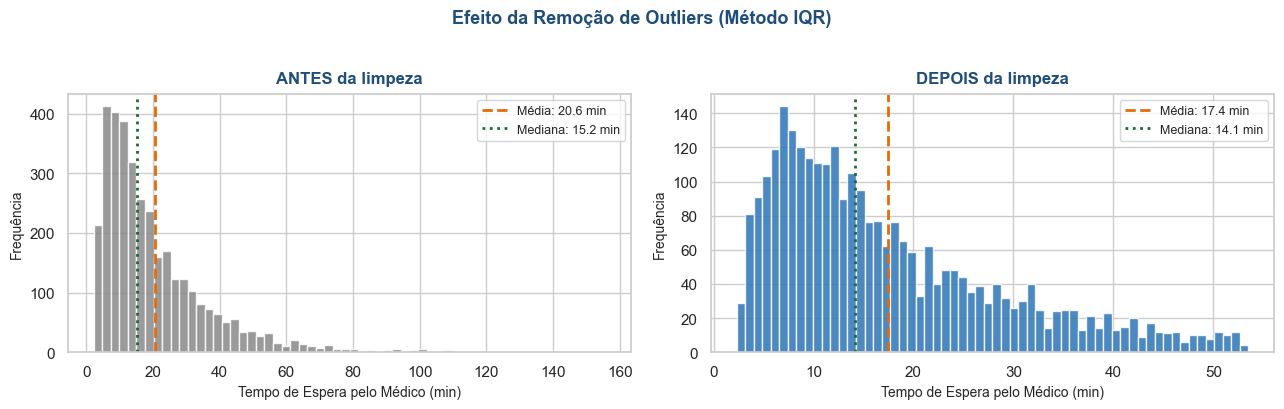


📊 Impacto da limpeza em 't_espera_medico_min':
   Média antes:   20.6 min  →  Média depois:  17.4 min
   Mediana antes: 15.2 min  →  Mediana depois: 14.1 min
   Desvio-padrão: 17.1  →  11.6


In [121]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 8 — Visualização: antes × depois da limpeza
# Comparamos a distribuição de um campo antes e após remover outliers
# ─────────────────────────────────────────────────────────────────

campo_vis = "t_espera_medico_min"  # campo escolhido para visualização
label_vis = "Tempo de Espera pelo Médico (min)"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Efeito da Remoção de Outliers (Método IQR)",
    fontsize=13,
    fontweight="bold",
    color=AZUL,
    y=1.02,
)

# Paleta: antes em cinza, depois em azul
for ax, dados, titulo, cor in [
    (axes[0], df[campo_vis].dropna(), "ANTES da limpeza", "#888888"),
    (axes[1], df_clean[campo_vis].dropna(), "DEPOIS da limpeza", AZUL2),
]:
    ax.hist(dados, bins=60, color=cor, edgecolor="white", alpha=0.85)

    # Linha vertical na média
    media = dados.mean()
    ax.axvline(
        media,
        color=LARANJA,
        linewidth=2,
        linestyle="--",
        label=f"Média: {media:.1f} min",
    )

    # Linha vertical na mediana
    mediana = dados.median()
    ax.axvline(
        mediana,
        color=VERDE,
        linewidth=2,
        linestyle=":",
        label=f"Mediana: {mediana:.1f} min",
    )

    ax.set_title(titulo, fontweight="bold", color=AZUL, pad=8)
    ax.set_xlabel(label_vis, fontsize=10)
    ax.set_ylabel("Frequência", fontsize=10)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("fig1_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

# Imprime a diferença numérica
antes = df[campo_vis].dropna()
depois = df_clean[campo_vis].dropna()
print(f"\n📊 Impacto da limpeza em '{campo_vis}':")
print(
    f"   Média antes:   {antes.mean():.1f} min  →  Média depois:  {depois.mean():.1f} min"
)
print(
    f"   Mediana antes: {antes.median():.1f} min  →  Mediana depois: {depois.median():.1f} min"
)
print(f"   Desvio-padrão: {antes.std():.1f}  →  {depois.std():.1f}")

### 🔍 Interpretação dos histogramas

**Antes da limpeza:** A distribuição tem uma "cauda longa" à direita — são os outliers puxando a média para cima. A **média ≠ mediana** confirma assimetria.

**Depois da limpeza:** A distribuição fica mais concentrada. A média e a mediana se aproximam. Este é o valor que usaremos como parâmetro **μ** do nosso modelo de simulação.

> ⚠️ **Cuidado:** Remover outliers pode esconder informações reais. Sempre questione: _"Este valor é um erro de registro ou um caso legítimo?"_ Em PA, um paciente que ficou 8 horas pode ser um caso clínico complexo — não necessariamente um erro.


---

## Parte 6 — KPIs Operacionais

### 🎯 O que são KPIs na gestão de PA?

**KPI** (Key Performance Indicator) são métricas que resumem o desempenho operacional. Para calibrar o simulador de PA, precisamos de **quatro KPIs fundamentais**:

| KPI                         | Parâmetro do simulador          | Fonte       |
| --------------------------- | ------------------------------- | ----------- |
| Taxa de chegada λ por hora  | Taxa de chegada ao longo do dia | FHIR/HIS    |
| Volume por dia da semana    | Fator de escalonamento semanal  | FHIR/HIS    |
| Tempo de espera por risco   | Tempo de serviço μ por classe   | HIS/Triagem |
| Padrão hora × dia (heatmap) | Validação visual do modelo      | HIS         |

### 📈 Taxa de chegada λ (lambda)

λ é o parâmetro da **distribuição de Poisson** que usaremos para gerar chegadas no simulador. Uma vez calculado a partir dos dados reais, o simulador pode reproduzir fielmente o comportamento do PA.

```
λₕ = média de atendimentos que chegaram no período h (hora do dia)
   = soma de chegadas no período h / número de dias observados
```


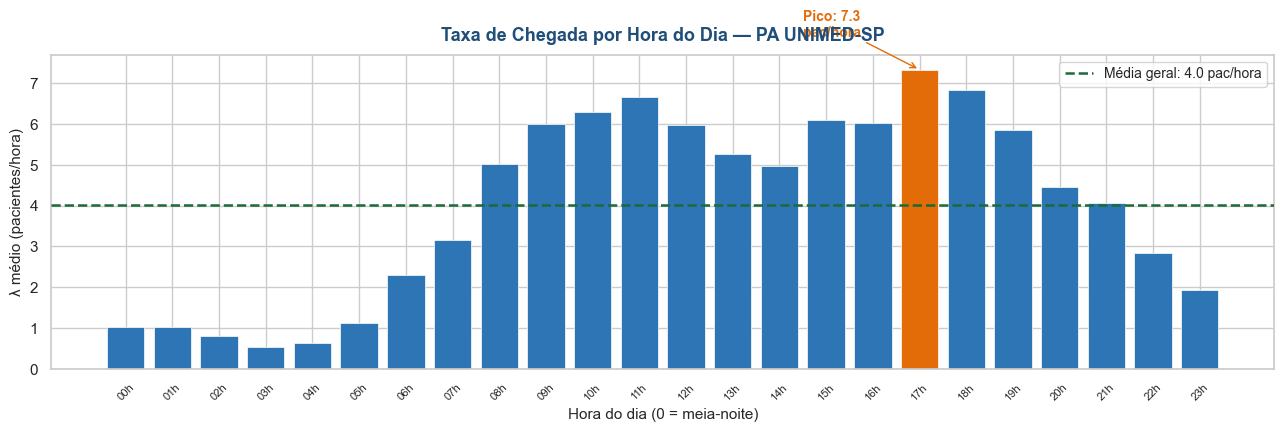


📊 Tabela de λ por hora (input para o simulador):
 hora_chegada  lambda_medio
            0      1.033333
            1      1.033333
            2      0.800000
            3      0.533333
            4      0.633333
            5      1.133333
            6      2.300000
            7      3.166667
            8      5.033333
            9      6.000000
           10      6.300000
           11      6.666667
           12      5.966667
           13      5.266667
           14      4.966667
           15      6.100000
           16      6.033333
           17      7.333333
           18      6.833333
           19      5.866667
           20      4.466667
           21      4.066667
           22      2.833333
           23      1.933333


In [122]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 9 — KPI 1: Taxa de chegada por hora do dia
# Este é o parâmetro λ que alimenta o módulo de chegadas no SimPy
# ─────────────────────────────────────────────────────────────────

# Calcula a média de atendimentos por hora considerando os 30 dias
# groupby('hora_chegada') agrupa todos os registros por hora (0–23)
# .size() conta os registros em cada grupo
# / 30 divide pelo número de dias para obter a média diária
taxa_hora = df_clean.groupby("hora_chegada").size().reset_index(name="total")
taxa_hora["lambda_medio"] = taxa_hora["total"] / 30  # média diária por hora

fig, ax = plt.subplots(figsize=(13, 4.5))

# Barras coloridas — laranja destaca o horário de pico
cores_barras = [
    (
        LARANJA
        if taxa_hora.loc[i, "lambda_medio"] == taxa_hora["lambda_medio"].max()
        else AZUL2
    )
    for i in range(len(taxa_hora))
]

bars = ax.bar(
    taxa_hora["hora_chegada"],
    taxa_hora["lambda_medio"],
    color=cores_barras,
    edgecolor="white",
    linewidth=0.5,
    width=0.8,
)

# Linha de média geral — referência para dimensionamento de recursos
media_geral = taxa_hora["lambda_medio"].mean()
ax.axhline(
    media_geral,
    color=VERDE,
    linewidth=1.8,
    linestyle="--",
    label=f"Média geral: {media_geral:.1f} pac/hora",
    zorder=5,
)

# Anotação no pico
hora_pico = taxa_hora.loc[taxa_hora["lambda_medio"].idxmax(), "hora_chegada"]
val_pico = taxa_hora["lambda_medio"].max()
ax.annotate(
    f"Pico: {val_pico:.1f}\npac/hora",
    xy=(hora_pico, val_pico),
    xytext=(hora_pico - 2.5, val_pico + 0.8),
    arrowprops=dict(arrowstyle="->", color=LARANJA),
    color=LARANJA,
    fontsize=10,
    fontweight="bold",
)

ax.set_title(
    "Taxa de Chegada por Hora do Dia — PA UNIMED-SP",
    fontsize=13,
    fontweight="bold",
    color=AZUL,
    pad=10,
)
ax.set_xlabel("Hora do dia (0 = meia-noite)", fontsize=11)
ax.set_ylabel("λ médio (pacientes/hora)", fontsize=11)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}h" for h in range(24)], rotation=45, fontsize=8)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig2_taxa_chegada.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Tabela de λ por hora (input para o simulador):")
print(taxa_hora[["hora_chegada", "lambda_medio"]].to_string(index=False))

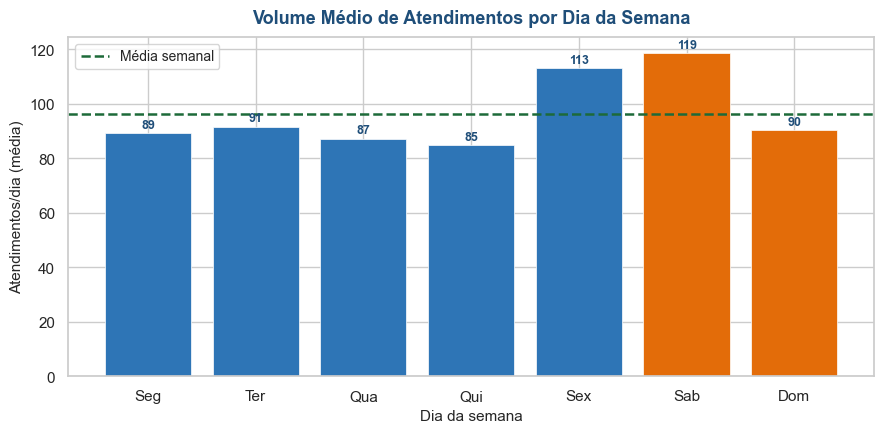


💡 Interpretação:
   Dia com MAIOR volume: Sab
   Dia com MENOR volume: Qui
   Variação pico-vale: 1.4x


In [123]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 10 — KPI 2: Volume por dia da semana
# Permite dimensionar a escala de pessoal adequada por dia
# ─────────────────────────────────────────────────────────────────

# Contagem de atendimentos por dia da semana
ordem_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
vol_dia = (
    df_clean.groupby("dia_semana")
    .size()
    .reindex(ordem_dias)  # garante ordem correta da semana
    .reset_index(name="total")
)
vol_dia["media_semanal"] = vol_dia["total"] / (30 / 7)  # média por semana

fig, ax = plt.subplots(figsize=(9, 4.5))

# Cores: fins de semana em laranja (geralmente maior volume por plantão reduzido)
cores_dias = [LARANJA if d in ["Sab", "Dom"] else AZUL2 for d in ordem_dias]

ax.bar(
    vol_dia["dia_semana"],
    vol_dia["media_semanal"],
    color=cores_dias,
    edgecolor="white",
    linewidth=0.5,
)

ax.axhline(
    vol_dia["media_semanal"].mean(),
    color=VERDE,
    linewidth=1.8,
    linestyle="--",
    label="Média semanal",
)

ax.set_title(
    "Volume Médio de Atendimentos por Dia da Semana",
    fontsize=13,
    fontweight="bold",
    color=AZUL,
    pad=10,
)
ax.set_xlabel("Dia da semana", fontsize=11)
ax.set_ylabel("Atendimentos/dia (média)", fontsize=11)
ax.legend(fontsize=10)

# Adiciona rótulo numérico em cima de cada barra
for i, v in enumerate(vol_dia["media_semanal"]):
    ax.text(
        i, v + 2, f"{v:.0f}", ha="center", fontsize=9, color=AZUL, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("fig3_volume_dia.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 Interpretação:")
print(
    f"   Dia com MAIOR volume: {vol_dia.loc[vol_dia.media_semanal.idxmax(),'dia_semana']}"
)
print(
    f"   Dia com MENOR volume: {vol_dia.loc[vol_dia.media_semanal.idxmin(),'dia_semana']}"
)
print(
    f"   Variação pico-vale: {vol_dia.media_semanal.max()/vol_dia.media_semanal.min():.1f}x"
)

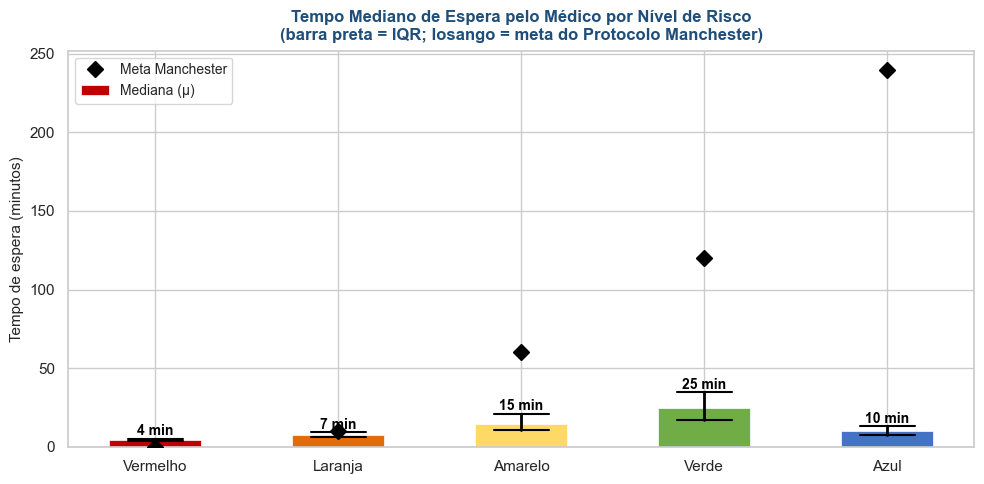


📊 Tabela de parâmetros μ por nível de risco:
   risco    n  media  mediana   Q1   Q3
Vermelho  179    4.5      4.3  3.5  5.2
 Laranja  448    8.0      7.4  6.0  9.5
 Amarelo  949   16.7     14.7 10.8 21.1
   Verde 1022   26.4     24.6 16.8 35.1
    Azul  291   10.8      9.8  7.6 13.0


In [124]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 11 — KPI 3: Tempo médio de espera por nível de risco Manchester
# Estes são os parâmetros μ (mu) do modelo de simulação
# ─────────────────────────────────────────────────────────────────

# Calculamos a mediana (mais robusta que a média para dados assimétricos)
# e o intervalo interquartil (Q1 a Q3) para mostrar a variabilidade
ordem_risco = ["Vermelho", "Laranja", "Amarelo", "Verde", "Azul"]
cores_risco = ["#C00000", "#E36C09", "#FFD966", "#70AD47", "#4472C4"]

espera_risco = (
    df_clean.groupby("risco_manchester")["t_espera_medico_min"]
    .agg(
        [
            "median",
            "mean",
            lambda s: s.quantile(0.25),
            lambda s: s.quantile(0.75),
            "count",
        ]
    )
    .reindex(ordem_risco)
    .reset_index()
)
espera_risco.columns = ["risco", "mediana", "media", "Q1", "Q3", "n"]

fig, ax = plt.subplots(figsize=(10, 5))

# Barra de mediana
bars = ax.bar(
    range(5),
    espera_risco["mediana"],
    color=cores_risco,
    edgecolor="white",
    linewidth=0.5,
    width=0.5,
    label="Mediana (μ)",
)

# Barra de erro = IQR (Q1 a Q3) — mostra a variabilidade
for i, row in espera_risco.iterrows():
    ax.plot([i, i], [row["Q1"], row["Q3"]], color="black", linewidth=2, zorder=5)
    ax.plot([i - 0.15, i + 0.15], [row["Q1"], row["Q1"]], color="black", linewidth=1.5)
    ax.plot([i - 0.15, i + 0.15], [row["Q3"], row["Q3"]], color="black", linewidth=1.5)
    ax.text(
        i,
        row["Q3"] + 2,
        f"{row['mediana']:.0f} min",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Linha de referência: metas do Protocolo de Manchester
metas = {"Vermelho": 0, "Laranja": 10, "Amarelo": 60, "Verde": 120, "Azul": 240}
for i, risco in enumerate(ordem_risco):
    meta = metas[risco]
    ax.plot(
        i,
        meta,
        "D",
        color="black",
        markersize=8,
        zorder=6,
        label="Meta Manchester" if i == 0 else "",
    )

ax.set_xticks(range(5))
ax.set_xticklabels(ordem_risco, fontsize=11)
ax.set_title(
    "Tempo Mediano de Espera pelo Médico por Nível de Risco\n(barra preta = IQR; losango = meta do Protocolo Manchester)",
    fontsize=12,
    fontweight="bold",
    color=AZUL,
    pad=8,
)
ax.set_ylabel("Tempo de espera (minutos)", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig4_espera_risco.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Tabela de parâmetros μ por nível de risco:")
print(
    espera_risco[["risco", "n", "media", "mediana", "Q1", "Q3"]].to_string(
        index=False, float_format="%.1f"
    )
)

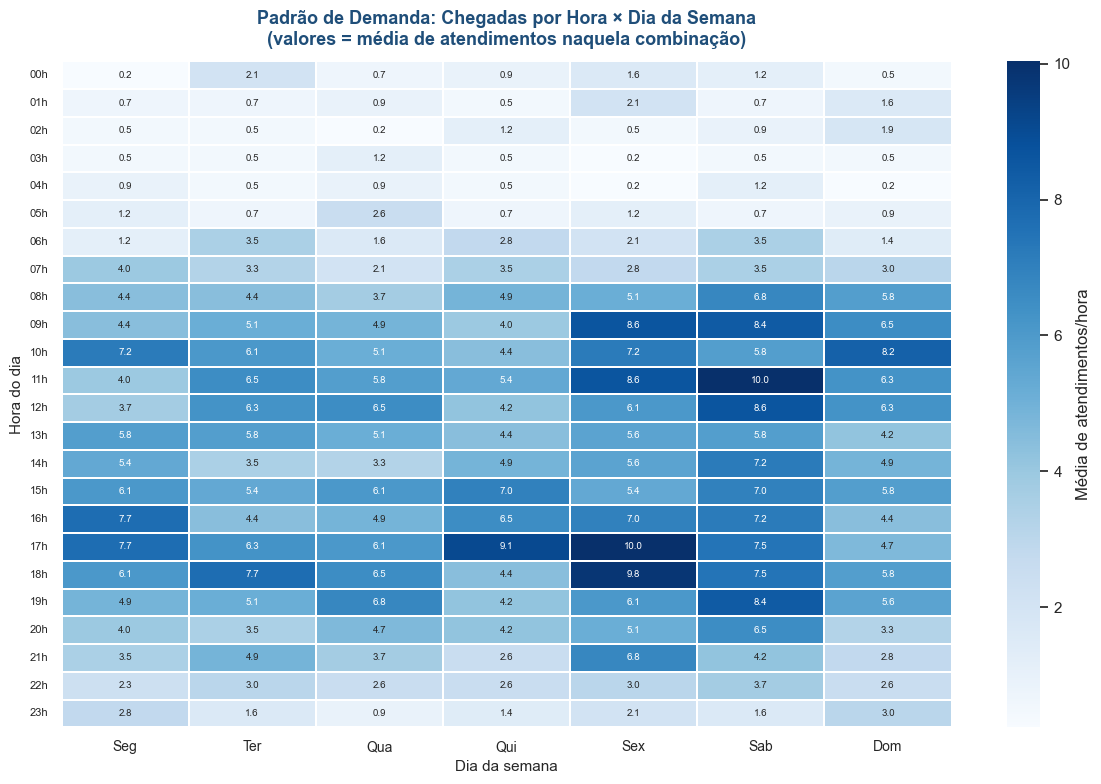


💡 Como ler o heatmap:
   Células MAIS ESCURAS = maior concentração de chegadas
   Identifica: horários de pico, dias críticos, períodos ociosos
   Uso prático: definir turnos e quantificar recursos por faixa horária


In [125]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 12 — KPI 4: Heatmap hora × dia da semana
# Visualiza o PADRÃO BIDIMENSIONAL de demanda — útil para escalas
# ─────────────────────────────────────────────────────────────────

# Tabela pivô: linhas = hora do dia (0-23), colunas = dia da semana
# valores = número médio de chegadas naquela combinação hora+dia
pivot = (
    df_clean.groupby(["hora_chegada", "dia_semana"])
    .size()
    .div(30 / 7)  # normaliza para média semanal
    .reset_index(name="media")
    .pivot(index="hora_chegada", columns="dia_semana", values="media")
    .reindex(columns=ordem_dias)  # ordena dias
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 8))

# Heatmap com escala de cores azul (mais escuro = mais pacientes)
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Média de atendimentos/hora"},
)

ax.set_title(
    "Padrão de Demanda: Chegadas por Hora × Dia da Semana\n(valores = média de atendimentos naquela combinação)",
    fontsize=13,
    fontweight="bold",
    color=AZUL,
    pad=12,
)
ax.set_xlabel("Dia da semana", fontsize=11)
ax.set_ylabel("Hora do dia", fontsize=11)

# Rotaciona rótulos dos eixos para melhor leitura
ax.set_yticklabels([f"{h:02d}h" for h in range(24)], rotation=0, fontsize=8)
ax.set_xticklabels(ordem_dias, rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("fig5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 Como ler o heatmap:")
print("   Células MAIS ESCURAS = maior concentração de chegadas")
print("   Identifica: horários de pico, dias críticos, períodos ociosos")
print("   Uso prático: definir turnos e quantificar recursos por faixa horária")

### 🔍 Interpretação dos KPIs

O heatmap revela o **padrão bidimensional de demanda** — informação impossível de capturar com uma simples média. Você deve conseguir identificar:

- **Faixa de maior demanda:** tarde/noite nos dias de semana
- **Fins de semana:** padrão diferente (menos manhã, mais tarde)
- **Madrugada:** demanda baixa e relativamente uniforme

> 🎯 **Uso no simulador:** Este heatmap define a **escala de chegadas variável no tempo** (`SimPy` suporta isso via `environment.timeout()`). Um modelo com λ constante seria menos preciso.


---

## Parte 7 — Integração com ERP: Escala e Leitos

### 🏢 O que o ERP fornece ao simulador?

Enquanto o **HIS** (via FHIR) fornece dados sobre **demanda** (pacientes chegando), o **ERP** fornece dados sobre **oferta** (recursos disponíveis):

```
HIS → demanda → chegadas, triagem, tempos de atendimento
ERP → oferta  → médicos disponíveis, leitos livres, equipamentos
```

**Em um hospital real**, a integração ERP→Simulador ocorre via:

1. **Query SQL direta** no banco do ERP (módulo de RH/escala)
2. **Exportação em CSV/Excel** agendada (batch noturno)
3. **API REST do ERP** (SAP, TOTVS, Oracle) — cada vez mais comum

Nesta aula, **simulamos a query SQL** que você executaria no ERP real:

```sql
-- Exemplo de query real no ERP hospitalar
SELECT
    turno,
    n_medicos_pa,
    n_enfermeiros,
    n_tecnicos
FROM tb_escala_pa
WHERE data_competencia = CURRENT_DATE
  AND setor_codigo = 'PA-ADULTO'
ORDER BY turno;
```

### 🛏️ Dados de leitos

O módulo de **gestão de leitos** do ERP registra:

- Capacidade total por ala
- Status de cada leito (ocupado, disponível, em manutenção, bloqueado)
- Taxa de ocupação histórica por período


In [126]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 13 — Escala de pessoal (simulando query SQL no ERP)
# Em produção: substituir por pd.read_sql() conectado ao banco ERP
# ─────────────────────────────────────────────────────────────────

# Escala típica de um PA de grande porte por turno
# Fonte: protocolos COFEN e CFM para dimensionamento de pessoal em PA
escala_erp = pd.DataFrame(
    {
        "turno": [
            "Noturno-1 (00h-07h)",  # plantão noturno cedo
            "Matutino  (07h-13h)",  # horário de maior fluxo
            "Vespertino(13h-19h)",  # segundo pico de demanda
            "Noturno-2 (19h-00h)",  # transição noite
        ],
        "n_medicos_pa": [2, 5, 4, 3],  # médicos no PA
        "n_enfermeiros": [3, 6, 5, 4],  # enfermeiros na triagem e obs.
        "n_tecnicos": [4, 8, 7, 5],  # técnicos de enfermagem
        "salas_atend": [3, 6, 5, 4],  # consultórios/salas disponíveis
    }
)

print("📋 Escala de pessoal — PA UNIMED-SP (via ERP):")
print(escala_erp.to_string(index=False))

# Calcula o índice médico:paciente por turno
# λ_turno = soma das taxas horárias do turno (simplificado)
lambdas_por_turno = {
    "Noturno-1 (00h-07h)": sum(TAXA_CHEGADA[h] for h in range(0, 7)),
    "Matutino  (07h-13h)": sum(TAXA_CHEGADA[h] for h in range(7, 13)),
    "Vespertino(13h-19h)": sum(TAXA_CHEGADA[h] for h in range(13, 19)),
    "Noturno-2 (19h-00h)": sum(TAXA_CHEGADA[h] for h in range(19, 24)),
}

escala_erp["lambda_turno"] = escala_erp["turno"].map(lambdas_por_turno)
escala_erp["pac_medico_turno"] = (
    escala_erp["lambda_turno"] / escala_erp["n_medicos_pa"]
).round(1)

print("\n📊 Carga média por médico no turno:")
print(
    escala_erp[["turno", "n_medicos_pa", "lambda_turno", "pac_medico_turno"]].to_string(
        index=False
    )
)

print("\n💡 Interpretação:")
print("   pac_medico_turno = pacientes chegando / médicos disponíveis no turno")
print("   Valores > 8 pac/médico/h podem indicar sobrecarga operacional")

📋 Escala de pessoal — PA UNIMED-SP (via ERP):
              turno  n_medicos_pa  n_enfermeiros  n_tecnicos  salas_atend
Noturno-1 (00h-07h)             2              3           4            3
Matutino  (07h-13h)             5              6           8            6
Vespertino(13h-19h)             4              5           7            5
Noturno-2 (19h-00h)             3              4           5            4

📊 Carga média por médico no turno:
              turno  n_medicos_pa  lambda_turno  pac_medico_turno
Noturno-1 (00h-07h)             2           9.2               4.6
Matutino  (07h-13h)             5          40.5               8.1
Vespertino(13h-19h)             4          46.4              11.6
Noturno-2 (19h-00h)             3          27.0               9.0

💡 Interpretação:
   pac_medico_turno = pacientes chegando / médicos disponíveis no turno
   Valores > 8 pac/médico/h podem indicar sobrecarga operacional


🛏️  Situação atual dos leitos — UNIMED-SP (via ERP):
           ala  capacidade  taxa_ocup  leitos_ocup  leitos_livres
     PA Adulto          20       0.78           16              4
 Observação PA          15       0.82           12              3
     UTI Geral          10       0.91            9              1
Clínica Médica          30       0.85           26              5
Cirurgia Geral          25       0.74           18              6
   Maternidade          20       0.68           14              6


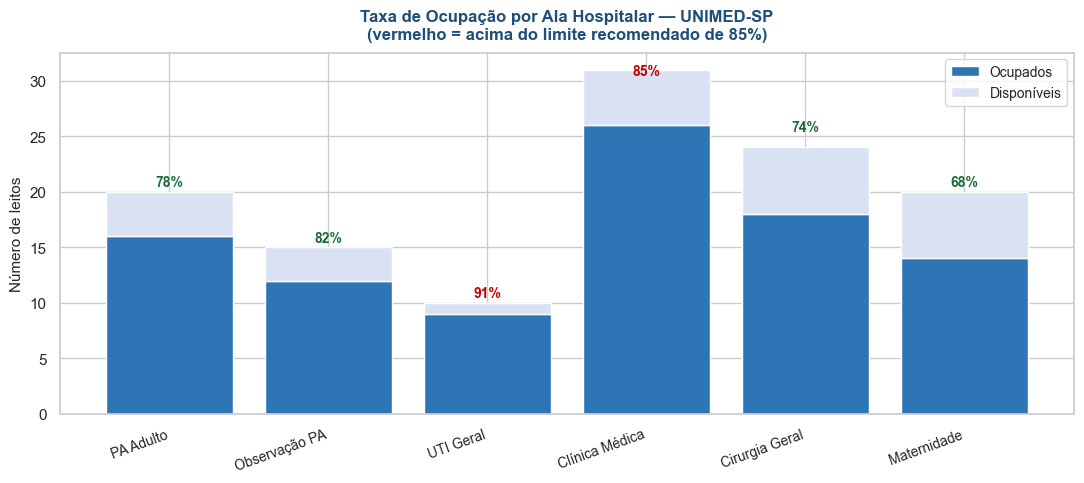


⚠️  Alas com ocupação ≥ 85% (risco de bloqueio de fluxo do PA):
           ala  capacidade  leitos_ocup  leitos_livres  taxa_ocup
     UTI Geral          10            9              1       0.91
Clínica Médica          30           26              5       0.85


In [127]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 14 — Disponibilidade de leitos (ERP — gestão de ativos)
# ─────────────────────────────────────────────────────────────────

# Estrutura de leitos por ala — dados típicos de um hospital de grande porte
ALAS = {
    "PA Adulto": {"capacidade": 20, "taxa_ocupacao": 0.78},
    "Observação PA": {"capacidade": 15, "taxa_ocupacao": 0.82},
    "UTI Geral": {"capacidade": 10, "taxa_ocupacao": 0.91},
    "Clínica Médica": {"capacidade": 30, "taxa_ocupacao": 0.85},
    "Cirurgia Geral": {"capacidade": 25, "taxa_ocupacao": 0.74},
    "Maternidade": {"capacidade": 20, "taxa_ocupacao": 0.68},
}

df_leitos = pd.DataFrame(
    [
        {
            "ala": nome,
            "capacidade": dados["capacidade"],
            "taxa_ocup": dados["taxa_ocupacao"],
            # leitos ocupados = capacidade × taxa de ocupação
            "leitos_ocup": round(dados["capacidade"] * dados["taxa_ocupacao"]),
            # leitos livres = capacidade - ocupados
            "leitos_livres": round(dados["capacidade"] * (1 - dados["taxa_ocupacao"])),
        }
        for nome, dados in ALAS.items()
    ]
)

print("🛏️  Situação atual dos leitos — UNIMED-SP (via ERP):")
print(df_leitos.to_string(index=False))

# ── Gráfico de ocupação por ala ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

x = range(len(df_leitos))

# Barras empilhadas: ocupados (azul) + livres (cinza claro)
ax.bar(x, df_leitos["leitos_ocup"], color=AZUL2, label="Ocupados", edgecolor="white")
ax.bar(
    x,
    df_leitos["leitos_livres"],
    bottom=df_leitos["leitos_ocup"],
    color="#D9E2F3",
    label="Disponíveis",
    edgecolor="white",
)

# Linha de alerta em 85% de ocupação (referência da ANS)
# Acima de 85%, o risco de não haver leito para pacientes graves aumenta
for i, row in df_leitos.iterrows():
    taxa = row["taxa_ocup"]
    cor_alerta = "#C00000" if taxa >= 0.85 else VERDE
    ax.text(
        i,
        row["capacidade"] + 0.5,
        f"{taxa*100:.0f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=cor_alerta,
    )

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_leitos["ala"], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Número de leitos", fontsize=11)
ax.set_title(
    "Taxa de Ocupação por Ala Hospitalar — UNIMED-SP\n(vermelho = acima do limite recomendado de 85%)",
    fontsize=12,
    fontweight="bold",
    color=AZUL,
    pad=10,
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig6_leitos.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n⚠️  Alas com ocupação ≥ 85% (risco de bloqueio de fluxo do PA):")
criticas = df_leitos[df_leitos["taxa_ocup"] >= 0.85]
if len(criticas) > 0:
    print(
        criticas[
            ["ala", "capacidade", "leitos_ocup", "leitos_livres", "taxa_ocup"]
        ].to_string(index=False)
    )
else:
    print("   Nenhuma ala em nível crítico no momento.")

### 🔍 Por que a taxa de ocupação de leitos impacta o PA?

Quando os leitos de **Clínica Médica** e **UTI** ficam acima de 85%, o PA não consegue transferir pacientes internados. Eles permanecem no PA ocupando macas e médicos — fenômeno chamado de **"boarding"**. Isso:

- Reduz a capacidade efetiva do PA
- Aumenta o tempo de espera para todos os pacientes
- É um **parâmetro crítico** para o modelo de simulação

> 🎯 No simulador, isso se traduz em: _"Se leitos de internação disponíveis < 2, o tempo de atendimento no PA aumenta em 40%"_ — uma regra de negócio capturada via integração ERP.


---

## Parte 8 — Conformidade com a LGPD

### ⚖️ LGPD e dados de saúde

A **Lei Geral de Proteção de Dados** (Lei n.º 13.709/2018) classifica dados de saúde como **dados sensíveis** (art. 11), exigindo tratamento diferenciado.

**No contexto de integração HIS→Simulador:**

```
Dado Original (HIS)          Tratamento LGPD         Dado no Simulador
─────────────────────────    ─────────────────────    ─────────────────
CPF do paciente              Proibido — excluir       NÃO entra
Nome do paciente             Proibido — excluir       NÃO entra
Diagnóstico (CID-10)         Sensível — anonimizar    Categoria agregada
Horário de chegada           Pode agrupar             Faixa horária
Nível de triagem             Pode usar agregado        Proporção por nível
Tempo de espera              Pode usar estatística     Média, desvio-padrão
```

**Três níveis de sensibilidade:**

| Nível        | Descrição                         | Exemplo                          | Ação                     |
| ------------ | --------------------------------- | -------------------------------- | ------------------------ |
| 🔴 Proibido  | Identifica o paciente diretamente | CPF, nome, endereço              | Excluir totalmente       |
| 🟡 Sensível  | Pode identificar por combinação   | CID-10, diagnóstico              | Agregar ou pseudonimizar |
| 🟢 Permitido | Não identifica individualmente    | Tempo de espera, hora de chegada | Usar diretamente         |

### 🔐 Anonimização vs. Pseudonimização

- **Anonimização:** dado não pode ser re-identificado por nenhum meio razoável → não é dado pessoal
- **Pseudonimização:** dado pode ser re-identificado com informação adicional → ainda é dado pessoal

Para simulação, **anonimização** é suficiente e mais simples.


In [128]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 15 — Classificação de campos conforme LGPD
# ─────────────────────────────────────────────────────────────────

# Definição de cada campo e sua classificação de sensibilidade
CAMPOS_LGPD = [
    # (campo_no_sistema, classificacao, justificativa, acao)
    (
        "id_anonimizado",
        "🟢 Permitido",
        "Pseudônimo sem dados pessoais",
        "Usar como chave técnica",
    ),
    (
        "dt_chegada",
        "🟡 Sensível",
        "Combinado com outros pode identificar",
        "Truncar para faixa horária",
    ),
    (
        "risco_manchester",
        "🟡 Sensível",
        "Dado clínico de triagem",
        "Usar apenas em forma agregada",
    ),
    (
        "hora_chegada",
        "🟢 Permitido",
        "Dado agregado sem identificação",
        "Usar diretamente",
    ),
    (
        "dia_semana",
        "🟢 Permitido",
        "Dado agregado sem identificação",
        "Usar diretamente",
    ),
    (
        "t_espera_triagem_min",
        "🟢 Permitido",
        "Estatística operacional",
        "Usar como parâmetro μ",
    ),
    (
        "t_espera_medico_min",
        "🟢 Permitido",
        "Estatística operacional",
        "Usar como parâmetro μ",
    ),
    (
        "t_atendimento_min",
        "🟢 Permitido",
        "Estatística operacional",
        "Usar como parâmetro μ",
    ),
]

df_lgpd = pd.DataFrame(
    CAMPOS_LGPD, columns=["Campo", "Classificação", "Justificativa", "Ação recomendada"]
)

print("=" * 90)
print("  CLASSIFICAÇÃO LGPD — CAMPOS DO DATASET DE SIMULAÇÃO")
print("=" * 90)
print(df_lgpd.to_string(index=False))

# Resumo
n_perm = sum(1 for _, c, _, _ in CAMPOS_LGPD if "Permitido" in c)
n_sens = sum(1 for _, c, _, _ in CAMPOS_LGPD if "Sensível" in c)
n_proib = sum(1 for _, c, _, _ in CAMPOS_LGPD if "Proibido" in c)

print(f"\n📊 Resumo:")
print(f"   🟢 Permitido:  {n_perm} campos — podem ir para o simulador diretamente")
print(f"   🟡 Sensível:   {n_sens} campos — precisam de tratamento antes do uso")
print(f"   🔴 Proibido:   {n_proib} campos — não devem sair do HIS")
print(f"\n✅ Todos os campos do nosso dataset estão dentro da LGPD.")
print("   (Os dados pessoais foram excluídos na geração do dataset sintético)")

  CLASSIFICAÇÃO LGPD — CAMPOS DO DATASET DE SIMULAÇÃO
               Campo Classificação                         Justificativa              Ação recomendada
      id_anonimizado   🟢 Permitido         Pseudônimo sem dados pessoais       Usar como chave técnica
          dt_chegada    🟡 Sensível Combinado com outros pode identificar    Truncar para faixa horária
    risco_manchester    🟡 Sensível               Dado clínico de triagem Usar apenas em forma agregada
        hora_chegada   🟢 Permitido       Dado agregado sem identificação              Usar diretamente
          dia_semana   🟢 Permitido       Dado agregado sem identificação              Usar diretamente
t_espera_triagem_min   🟢 Permitido               Estatística operacional         Usar como parâmetro μ
 t_espera_medico_min   🟢 Permitido               Estatística operacional         Usar como parâmetro μ
   t_atendimento_min   🟢 Permitido               Estatística operacional         Usar como parâmetro μ

📊 Resumo:
   🟢 Per

---

## Parte 9 — Tabela de Inputs para o Simulador

### 🎯 A entrega final: parâmetros para o modelo SimPy

Esta é a **etapa de integração final** do pipeline de dados. Após coletar dados do HIS (via FHIR) e do ERP, e após limpar e calcular os KPIs, construímos a **tabela de inputs** que alimenta o modelo de simulação de eventos discretos.

**Estrutura de inputs necessários para um modelo SimPy de PA:**

```python
# Exemplo de uso no simulador (aula D10)
import simpy

env = simpy.Environment()

# Input 1: médicos como Resource com capacidade do ERP
medicos = simpy.Resource(env, capacity=n_medicos_turno)

# Input 2: chegadas com λ variável (do HIS via FHIR)
def chegadas(env, lambda_hora):
    while True:
        yield env.timeout(np.random.exponential(60 / lambda_hora))
        # processa atendimento...

# Input 3: tempo de serviço por risco (do HIS)
def atendimento(risco):
    mu, sigma = parametros_por_risco[risco]
    return np.random.lognormal(mu, sigma)
```

### 📦 Quatro tabelas de saída

| Arquivo CSV             | Conteúdo                  | Usado no simulador para     |
| ----------------------- | ------------------------- | --------------------------- |
| `inputs_chegada_pa.csv` | λ por faixa horária de 6h | chegadas variáveis no tempo |
| `inputs_servico_pa.csv` | μ e σ por nível de risco  | tempo de atendimento        |
| `inputs_escala_erp.csv` | médicos/salas por turno   | capacidade de recursos      |
| `inputs_leitos_erp.csv` | ocupação por ala          | restrições de internação    |


In [129]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 16 — Tabela de inputs: chegadas por faixa horária de 6h
# Agrupamos em blocos de 6h para alinhar com os turnos do ERP
# ─────────────────────────────────────────────────────────────────

# Cria faixas horárias de 6h: [0-6h), [6-12h), [12-18h), [18-24h)
df_clean["faixa_6h"] = pd.cut(
    df_clean["hora_chegada"],
    bins=[0, 6, 12, 18, 24],
    right=False,
    labels=["00h-06h", "06h-12h", "12h-18h", "18h-24h"],
)

# Calcula λ (taxa por hora) para cada faixa
# total_faixa / 30_dias / 6_horas = chegadas por hora nesta faixa
inputs_chegada = (
    df_clean.groupby("faixa_6h", observed=True).size().reset_index(name="total_30_dias")
)
inputs_chegada["lambda_hora"] = (inputs_chegada["total_30_dias"] / 30 / 6).round(2)
inputs_chegada["intervalo_medio_min"] = (60 / inputs_chegada["lambda_hora"]).round(1)

print("📊 INPUT 1 — Taxa de chegada por faixa horária:")
print("(λ = chegadas/hora | Intervalo = minutos entre chegadas)")
print()
print(inputs_chegada.to_string(index=False))
print()
print("Uso no SimPy:")
print("  yield env.timeout(np.random.exponential(intervalo_medio_min))")

📊 INPUT 1 — Taxa de chegada por faixa horária:
(λ = chegadas/hora | Intervalo = minutos entre chegadas)

faixa_6h  total_30_dias  lambda_hora  intervalo_medio_min
 00h-06h            155         0.86                 69.8
 06h-12h            884         4.91                 12.2
 12h-18h           1070         5.94                 10.1
 18h-24h            780         4.33                 13.9

Uso no SimPy:
  yield env.timeout(np.random.exponential(intervalo_medio_min))


In [132]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 17 — Tabela de inputs: tempo de serviço por nível de risco
# Estes parâmetros definem a distribuição Lognormal de cada classe
# ─────────────────────────────────────────────────────────────────

from scipy.stats import lognorm
import numpy as np

inputs_servico = []
for risco in ordem_risco:
    dados = df_clean[df_clean["risco_manchester"] == risco][
        "t_atendimento_min"
    ].dropna()

    if len(dados) > 10:
        # Ajuste da distribuição Lognormal aos dados observados
        # lognorm.fit retorna (sigma, loc, scale) onde mu = log(scale)
        sigma, loc, scale = lognorm.fit(dados, floc=0)  # floc=0 fixa location em 0
        mu_estimado = np.log(scale)  # mu da distribuição do log

        inputs_servico.append(
            {
                "risco_manchester": risco,
                "n_atendimentos": len(dados),
                "media_min": round(dados.mean(), 1),
                "mediana_min": round(dados.median(), 1),
                "desvio_min": round(dados.std(), 1),
                "mu_lognormal": round(mu_estimado, 3),  # parâmetro μ para SimPy
                "sigma_lognormal": round(sigma, 3),  # parâmetro σ para SimPy
                "P10_min": round(dados.quantile(0.10), 1),
                "P90_min": round(dados.quantile(0.90), 1),
            }
        )

inputs_servico_df = pd.DataFrame(inputs_servico)
print("📊 INPUT 2 — Parâmetros de tempo de atendimento por nível de risco:")
print("(mu e sigma são usados em: np.random.lognormal(mu, sigma))")
print()
print(inputs_servico_df.to_string(index=False))
print()
print("Uso no SimPy:")
print("  t_atend = np.random.lognormal(mu_lognormal, sigma_lognormal)")
print("  yield env.timeout(t_atend)")

📊 INPUT 2 — Parâmetros de tempo de atendimento por nível de risco:
(mu e sigma são usados em: np.random.lognormal(mu, sigma))

risco_manchester  n_atendimentos  media_min  mediana_min  desvio_min  mu_lognormal  sigma_lognormal  P10_min  P90_min
        Vermelho             179       21.2         20.5         6.0         3.014            0.278     14.4     29.8
         Laranja             448       36.3         33.6        16.5         3.510            0.396     20.3     54.8
         Amarelo             949       75.1         67.9        38.4         4.193            0.510     34.0    129.2
           Verde            1022      120.4        115.2        53.3         4.680            0.494     53.1    198.2
            Azul             291       47.4         41.6        20.7         3.769            0.423     24.9     77.6

Uso no SimPy:
  t_atend = np.random.lognormal(mu_lognormal, sigma_lognormal)
  yield env.timeout(t_atend)


In [131]:
# ─────────────────────────────────────────────────────────────────
# CÉLULA 18 — Exportação de todos os CSVs para o simulador
# ─────────────────────────────────────────────────────────────────

import os

# Diretório de saída (mesma pasta do notebook)
OUTPUT_DIR = ""

# ── CSV 1: Inputs de chegada ───────────────────────────────────
path_chegada = os.path.join(OUTPUT_DIR, "inputs_chegada_pa.csv")
inputs_chegada.to_csv(path_chegada, index=False, encoding="utf-8")

# ── CSV 2: Inputs de serviço ───────────────────────────────────
path_servico = os.path.join(OUTPUT_DIR, "inputs_servico_pa.csv")
inputs_servico_df.to_csv(path_servico, index=False, encoding="utf-8")

# ── CSV 3: Escala do ERP ───────────────────────────────────────
path_escala = os.path.join(OUTPUT_DIR, "inputs_escala_erp.csv")
escala_erp.to_csv(path_escala, index=False, encoding="utf-8")

# ── CSV 4: Leitos do ERP ──────────────────────────────────────
path_leitos = os.path.join(OUTPUT_DIR, "inputs_leitos_erp.csv")
df_leitos.to_csv(path_leitos, index=False, encoding="utf-8")

print("✅ Arquivos exportados com sucesso:")
for label, path in [
    ("Chegadas (λ por faixa)", path_chegada),
    ("Serviço (μ,σ por risco)", path_servico),
    ("Escala ERP", path_escala),
    ("Leitos ERP", path_leitos),
]:
    size_kb = os.path.getsize(path) / 1024
    print(f"   📄 {label:25s} → {os.path.basename(path)} ({size_kb:.1f} KB)")

print()
print("📦 Estes arquivos são os INPUTS do modelo SimPy da próxima aula.")
print("   Guarde-os na mesma pasta do notebook de simulação.")

✅ Arquivos exportados com sucesso:
   📄 Chegadas (λ por faixa)    → inputs_chegada_pa.csv (0.1 KB)
   📄 Serviço (μ,σ por risco)   → inputs_servico_pa.csv (0.3 KB)
   📄 Escala ERP                → inputs_escala_erp.csv (0.2 KB)
   📄 Leitos ERP                → inputs_leitos_erp.csv (0.2 KB)

📦 Estes arquivos são os INPUTS do modelo SimPy da próxima aula.
   Guarde-os na mesma pasta do notebook de simulação.


---

## Parte 10 — Resumo do Pipeline de Integração

### 🔄 O que fizemos neste notebook

```
┌─────────────────────────────────────────────────────────────────┐
│              PIPELINE DE INTEGRAÇÃO — D9 UNIMED-SP              │
└─────────────────────────────────────────────────────────────────┘

  FONTES DE DADOS              PROCESSAMENTO           OUTPUTS
  ┌─────────────┐              ┌────────────────┐      ┌─────────────────────┐
  │  HIS / FHIR │──GET /Enc──▶ │ Limpeza IQR    │──▶   │ inputs_chegada.csv  │
  │  (HL7 R4)   │              │ Análise compl. │      │ inputs_servico.csv  │
  └─────────────┘              │ KPIs (λ, μ, σ) │      └─────────────────────┘
                               └────────────────┘
  ┌─────────────┐              ┌────────────────┐      ┌─────────────────────┐
  │   ERP       │──SQL/API──▶  │ Escala pessoal │──▶   │ inputs_escala.csv   │
  │  (TOTVS/SAP)│              │ Leitos livres  │      │ inputs_leitos.csv   │
  └─────────────┘              └────────────────┘      └─────────────────────┘
                                                               │
                                                               ▼
                                                       ┌───────────────┐
                                                       │  Modelo SimPy │
                                                       │  (Aula D10)   │
                                                       └───────────────┘
```

### ✅ O que cada parte aprendemos

| Parte | Conceito principal         | Técnica utilizada                |
| ----- | -------------------------- | -------------------------------- |
| 1     | Configuração e bibliotecas | pip, imports, rcParams           |
| 2     | API REST FHIR R4           | GET /Encounter, Bundle, JSON     |
| 3     | Extração de Encounters     | parsing de FHIR Bundle, fallback |
| 4     | Dataset sintético          | Poisson, Lognormal, Manchester   |
| 5     | Qualidade de dados         | completude, IQR, histogramas     |
| 6     | KPIs operacionais          | groupby, pivot, heatmap          |
| 7     | Integração ERP             | SQL simulado, leitos, escala     |
| 8     | LGPD                       | classificação de sensibilidade   |
| 9     | Tabela de inputs           | ajuste Lognormal, exportação CSV |

### 📚 Próximos passos

**Aula D10 — Modelagem com SimPy:**

- Importar os CSVs gerados aqui
- Construir o modelo de chegadas com λ variável
- Modelar filas de triagem e atendimento
- Executar cenários: _"e se aumentarmos 1 médico no turno vespertino?"_

### 📖 Referências

- HL7 International. _FHIR R4 Specification_. https://hl7.org/fhir/R4/ (2019)
- DATASUS/MS. _RNDS — Rede Nacional de Dados em Saúde_. https://rnds.saude.gov.br (2020)
- Hardt, D. _RFC 6749 — The OAuth 2.0 Authorization Framework_. IETF (2012)
- Tukey, J. W. _Exploratory Data Analysis_. Addison-Wesley (1977)
- Brasil. _Lei n.º 13.709/2018 — Lei Geral de Proteção de Dados (LGPD)_
- Gilks, W.R. et al. _Markov Chain Monte Carlo in Practice_. Chapman & Hall (1996)
- Banks, J. et al. _Discrete-Event System Simulation_. 5ª ed. Pearson (2010)
